In [1]:
"""
tod_skill.py -- does model skill hold across the trading day?
Slices the deployed model's holdout predictions by time-of-day and reports
discrimination + lamp performance per slot. Pure analysis of the existing
pred parquet; no model runs.

RULES
  T.1  Per-slot null is the SLOT's own base rate: skill_slot =
       1 - LL_slot(p_cal) / LL_slot(const_slot). This measures information
       beyond "what time is it", which is the honest per-slot question.
  T.2  RED/GREEN performance per slot uses the GLOBAL frozen thresholds
       (the lamp as deployed), so red_precision per slot answers: "when the
       lamp is RED at the time I trade, how often is it right THERE."
  T.3  Two resolutions: 30-min slots across the session, and FINE_BIN-minute
       slots over [FINE_FROM, FINE_TO) for the open/macro windows.
"""

import json
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------------- CONFIG
FRAME = 3
STAGE0_TAG = 'mnq-TICK-9-12am'
BODY_TAG = "raw"

PRED_PATH = f"stage-5/pred_{BODY_TAG}_{STAGE0_TAG}_{FRAME}s.pqt"

GREEN_MAX = 0.00310          # from THIS model's decile table (3s TICK 9-12)
RED_MIN = 0.373
SESSION_START = "09:00"      # slot origin; match the model's session
EVAL_FROM = "2026-01-01"     # 2026-only, simple + reliable

FINE_FROM = "09:00"          # fine-grain window (open + macro releases)
FINE_TO = "12:00"
FINE_BIN = 15                 # minutes
PLOT = True

# longitudinal analyzer (window_over_time)
ROLL_DAYS = 20              # rolling-median span for the trend overlay
TS_METRICS = ["skill", "auc", "red_precision", "base_rate"]
# ----------------------------------------------------------------

In [2]:
def ll(y, p):
    p = np.clip(np.asarray(p, np.float64), 1e-12, 1 - 1e-12)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def slot_metrics(g):
    y = g["is_target"].to_numpy(np.float64)
    p = g["p_cal"].to_numpy(np.float64)
    r = y.mean()
    m = {"n": int(len(g)), "targets": int(y.sum()), "base_rate": float(r)}
    m["skill"] = 1.0 - ll(y, p) / ll(y, np.full_like(y, r))               # T.1
    m["auc"] = float(roc_auc_score(y, p)) if 0 < y.sum() < len(y) else np.nan
    red = p >= RED_MIN                                                     # T.2
    m["red_frac"] = float(red.mean())
    m["red_precision"] = float(y[red].mean()) if red.any() else np.nan
    green = p < GREEN_MAX
    m["green_break"] = float(y[green].mean()) if green.any() else np.nan
    return m


def by_slot(pred, minutes):
    mod = pred["timestamp"].dt.hour * 60 + pred["timestamp"].dt.minute

    origin = pd.Timestamp(SESSION_START).hour * 60 + pd.Timestamp(SESSION_START).minute
    slot = (mod - origin) // minutes

    rows = []
    for s, g in pred.groupby(slot):
        m = slot_metrics(g)
        lo = origin + s * minutes
        m["slot"] = f"{lo // 60:02d}:{lo % 60:02d}"
        rows.append(m)
    cols = ["slot", "n", "targets", "base_rate", "skill", "auc",
            "red_frac", "red_precision", "green_break"]
    return pd.DataFrame(rows)[cols]


def analyze_window(pred, start, end, sub_bin=None):
    """Pool all holdout days over [start, end); aggregate metrics + calibration
    table + optional sub-bin breakdown. Returns (aggregate_dict, decile_table)."""
    lo = pd.Timestamp(start).time()
    hi = pd.Timestamp(end).time()
    w = pred[(pred["timestamp"].dt.time >= lo) & (pred["timestamp"].dt.time < hi)]
    n_days = w["timestamp"].dt.date.nunique()

    m = slot_metrics(w)
    m["window"] = f"{start}-{end}"
    m["n_days"] = int(n_days)
    print(f"==== {start}-{end}  ({n_days} days, {len(w)} bars, "
          f"{int(w['is_target'].sum())} targets) ====")
    print(json.dumps({k: (round(v, 5) if isinstance(v, float) else v)
                      for k, v in m.items()}, indent=2))

    cuts = np.quantile(pred["p_cal"], np.arange(0.1, 1.0, 0.1))          # global cuts
    y = w["is_target"].to_numpy(np.float64)
    b = np.searchsorted(cuts, w["p_cal"].to_numpy())
    tbl = pd.DataFrame({"bin": b, "p": w["p_cal"].to_numpy(), "y": y}).groupby(
        "bin").agg(n=("y", "size"), mean_p=("p", "mean"),
                   realized=("y", "mean")).reindex(range(10))
    print("---- calibration in window (global decile cuts) ----")
    print(tbl.to_string())

    sub = None
    if sub_bin:
        sub = by_slot(w, sub_bin)
        print(f"---- {sub_bin}-min sub-bins ----")
        print(sub.to_string(index=False))

    if PLOT:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        rows = 2 if sub is not None else 1
        titles = ["calibration in window (realized vs predicted per decile)"]
        if sub is not None:
            titles.append(f"skill / red_precision by {sub_bin}-min sub-bin")
        fig = make_subplots(rows=rows, cols=1, vertical_spacing=0.12,
                            subplot_titles=titles)
        d = tbl.dropna()
        fig.add_trace(go.Scatter(x=d["mean_p"], y=d["realized"], mode="markers",
                                 name="realized", marker=dict(size=9)), row=1, col=1)
        lim = float(np.nanmax(d["mean_p"].to_numpy())) if len(d) else 1.0
        fig.add_trace(go.Scatter(x=[0, lim], y=[0, lim], mode="lines",
                                 line=dict(dash="dot", color="black"),
                                 name="ideal"), row=1, col=1)
        if sub is not None:
            fig.add_trace(go.Scatter(x=sub["slot"], y=sub["skill"],
                                     mode="lines+markers", name="skill"), row=2, col=1)
            fig.add_trace(go.Scatter(x=sub["slot"], y=sub["red_precision"],
                                     mode="lines+markers", name="red_precision"),
                          row=2, col=1)
        fig.update_layout(height=380 * rows, width=1000, template="plotly_white",
                          title=f"window {start}-{end}, {n_days} days")
        fig.update_xaxes(title_text="predicted p_cal", row=1, col=1)
        fig.update_yaxes(title_text="realized", row=1, col=1)
        fig.show()

    return m, tbl

In [3]:
def window_over_time(pred, start, end, roll=ROLL_DAYS, metrics_list=None):
    """Fix intraday window [start,end); one point per calendar day; plot each
    metric across the date axis with a rolling-median trend. Per-day skill on a
    30-min window rests on ~30 targets -- read the trend, not the scatter."""
    metrics_list = metrics_list or TS_METRICS
    lo = pd.Timestamp(start).time()
    hi = pd.Timestamp(end).time()
    w = pred[(pred["timestamp"].dt.time >= lo) & (pred["timestamp"].dt.time < hi)]

    rows = []
    for day, g in w.groupby(w["timestamp"].dt.date, sort=True):
        m = slot_metrics(g)
        m["date"] = pd.Timestamp(day)
        rows.append(m)
    ts = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    for k in metrics_list:
        ts[k + "_roll"] = ts[k].rolling(roll, min_periods=max(3, roll // 2),
                                        center=True).median()

    print(f"==== {start}-{end} over {len(ts)} days ({ts['date'].min().date()} .. {ts['date'].max().date()}) ====")
    print(f"per-day avg: {int(ts['n'].mean())} bars, {int(ts['targets'].mean())} targets")
    yr = ts.assign(year=ts["date"].dt.year).groupby("year").agg({k: "median" for k in metrics_list} | {"targets": "median"})
    print("---- per-year median of daily metric ----")
    print(yr.to_string())

    if PLOT:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        fig = make_subplots(rows=len(metrics_list), cols=1, shared_xaxes=True, vertical_spacing=0.04, subplot_titles=metrics_list)
        for i, k in enumerate(metrics_list):
            fig.add_trace(go.Scatter(x=ts["date"], y=ts[k], mode="markers", marker=dict(size=3, color="black"), name=f"{k} daily", showlegend=False), row=i + 1, col=1)
            fig.add_trace(go.Scatter(x=ts["date"], y=ts[k + "_roll"], mode="lines", line=dict(width=2), name=f"{k} {roll}d median", showlegend=False), row=i + 1, col=1)
        fig.update_layout(height=260 * len(metrics_list), width=2400, template="plotly_white", title=f"{start}-{end} daily metrics over time ({roll}d rolling median)")
        fig.show()

    return ts

In [4]:
def run():
    pred = pd.read_parquet(PRED_PATH)
    pred = pred[pred["timestamp"] >= EVAL_FROM]
    print(pred.head())
    
    coarse = by_slot(pred, 30)
    print("---- 30-minute slots ----")
    print(coarse.to_string(index=False))

    lo = pd.Timestamp(FINE_FROM).time()
    hi = pd.Timestamp(FINE_TO).time()
    fine = by_slot(pred[(pred["timestamp"].dt.time >= lo) & (pred["timestamp"].dt.time < hi)], FINE_BIN)
    
    print(f"---- {FINE_BIN}-minute slots, {FINE_FROM}-{FINE_TO} ----")
    print(fine.to_string(index=False))

    g = pred.assign(mod=pred["timestamp"].dt.hour * 60 + pred["timestamp"].dt.minute)
    worst = coarse.sort_values("skill").head(3)
    
    print("---- weakest 30-min slots ----")
    print(worst.to_string(index=False))

    if PLOT:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06, subplot_titles=["skill / AUC by 30-min slot", "red_precision / base_rate by slot"])
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["skill"], mode="lines+markers", name="skill"), row=1, col=1)
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["auc"], mode="lines+markers", name="auc"), row=1, col=1)
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["red_precision"], mode="lines+markers", name="red_precision"), row=2, col=1)
        fig.add_trace(go.Scatter(x=coarse["slot"], y=coarse["base_rate"], mode="lines+markers", name="base_rate"), row=2, col=1)
        fig.update_layout(height=700, width=1300, template="plotly_white", hovermode="x unified")
        fig.show()

        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06, subplot_titles=[f"skill / AUC by {FINE_BIN}-min slot", "red_precision / base_rate by slot"])
        fig.add_trace(go.Scatter(x=fine["slot"], y=fine["skill"], mode="lines+markers", name="skill"), row=1, col=1)
        fig.add_trace(go.Scatter(x=fine["slot"], y=fine["auc"], mode="lines+markers", name="auc"), row=1, col=1)
        fig.add_trace(go.Scatter(x=fine["slot"], y=fine["red_precision"], mode="lines+markers", name="red_precision"), row=2, col=1)
        fig.add_trace(go.Scatter(x=fine["slot"], y=fine["base_rate"], mode="lines+markers", name="base_rate"), row=2, col=1)
        fig.update_layout(height=700, width=1300, template="plotly_white", hovermode="x unified")
        fig.show()
        
    return coarse, fine, pred

   bar_index           timestamp  is_target         p     p_cal
0    3641370 2026-01-02 09:00:30      False  0.105028  0.117386
1    3641371 2026-01-02 09:00:33      False  0.144235  0.167247
2    3641372 2026-01-02 09:00:36      False  0.179906  0.198428
3    3641373 2026-01-02 09:00:39      False  0.228456  0.253829
4    3641374 2026-01-02 09:00:42      False  0.214984  0.250453
---- 30-minute slots ----
 slot     n  targets  base_rate    skill      auc  red_frac  red_precision  green_break
09:00 78433     8265   0.105377 0.551100 0.955485  0.103439       0.704672     0.001160
09:30 79792     8528   0.106878 0.638246 0.972177  0.107317       0.756394     0.000863
10:00 79794     8147   0.102100 0.658009 0.976141  0.107489       0.744899     0.000419
10:30 79796     8183   0.102549 0.656711 0.975898  0.106371       0.748468     0.000372
11:00 79795     8222   0.103039 0.643193 0.973927  0.106523       0.742941     0.000335
11:30 79788     8238   0.103249 0.638370 0.973240  0.105028   

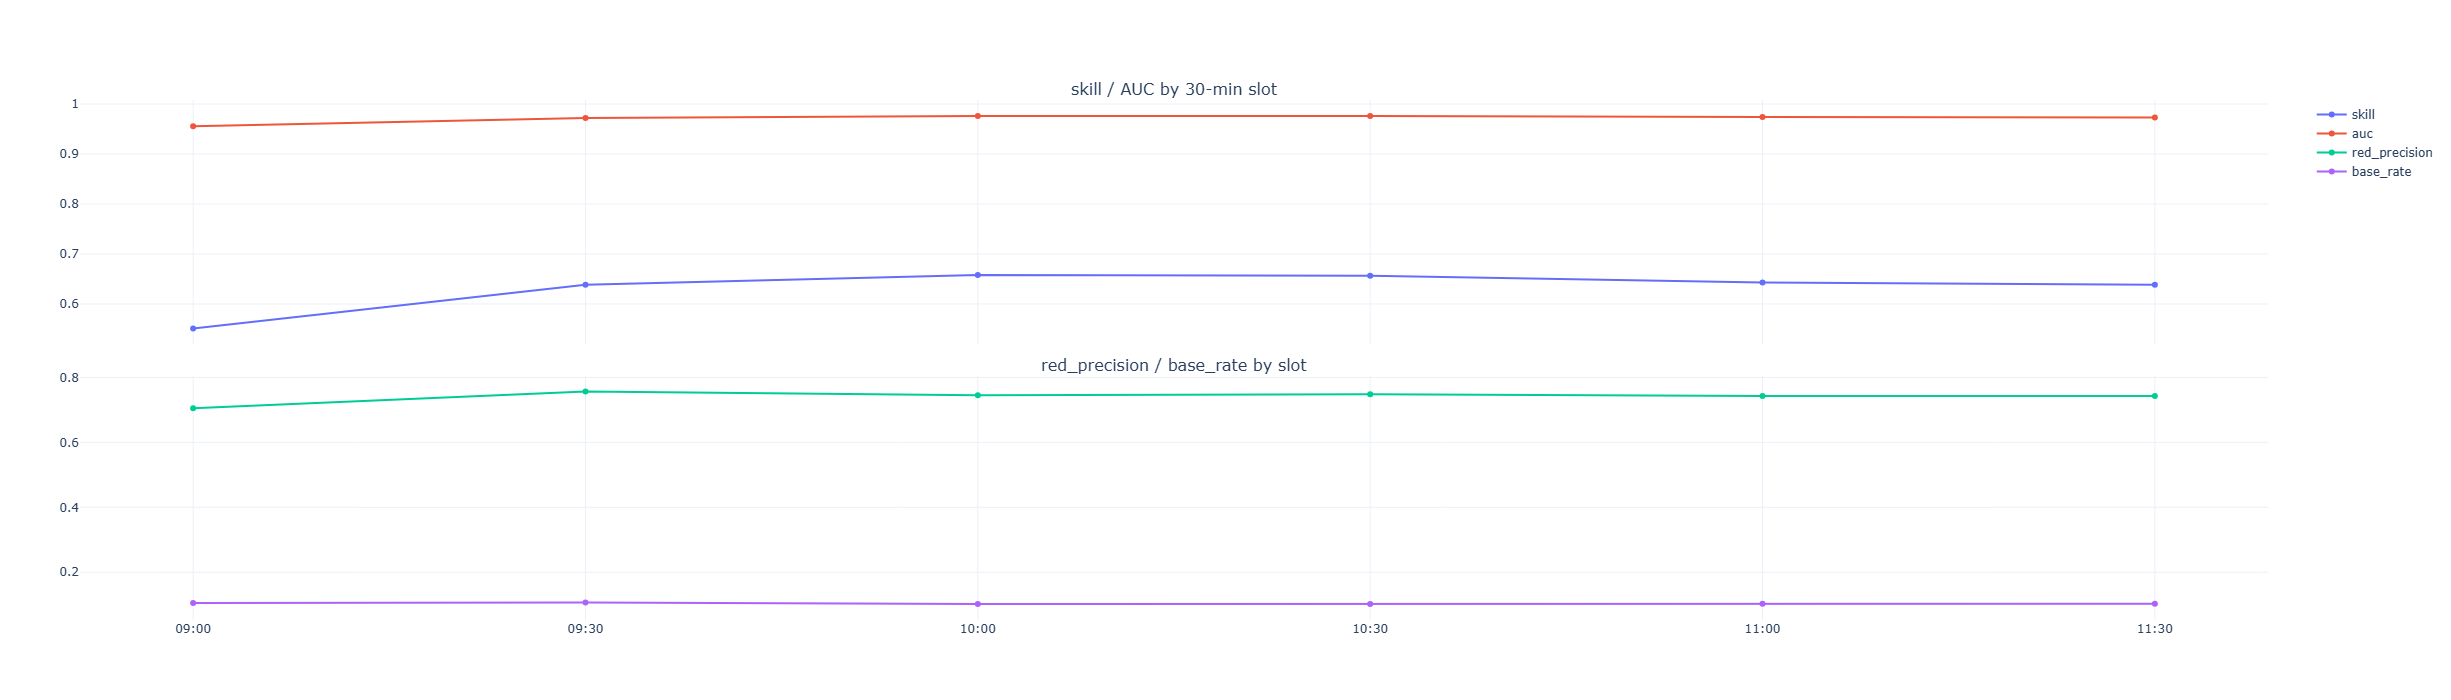

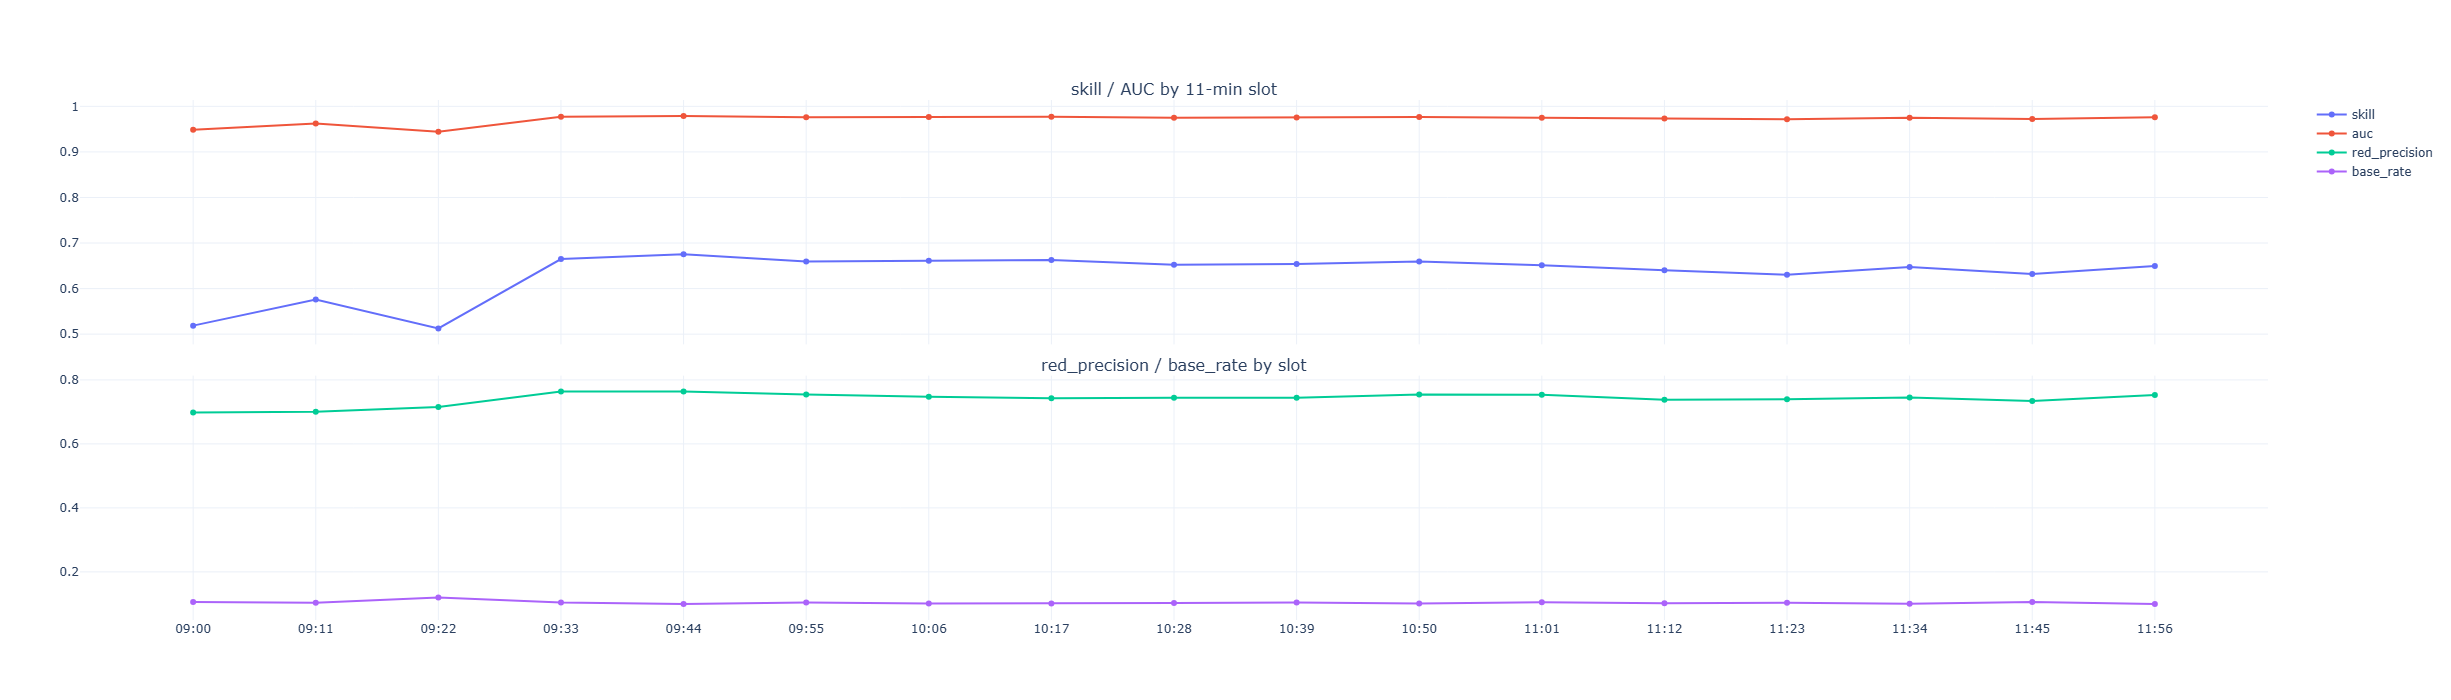

In [5]:
# ---------------------------------------------------------------- usage
FINE_BIN = 11                 # minutes

coarse, fine, pred = run() 

==== 09:30-10:00 over 133 days (2026-01-02 .. 2026-07-08) ====
per-day avg: 599 bars, 64 targets
---- per-year median of daily metric ----
         skill       auc  red_precision  base_rate  targets
year                                                       
2026  0.646371  0.973785       0.766234   0.108333     65.0


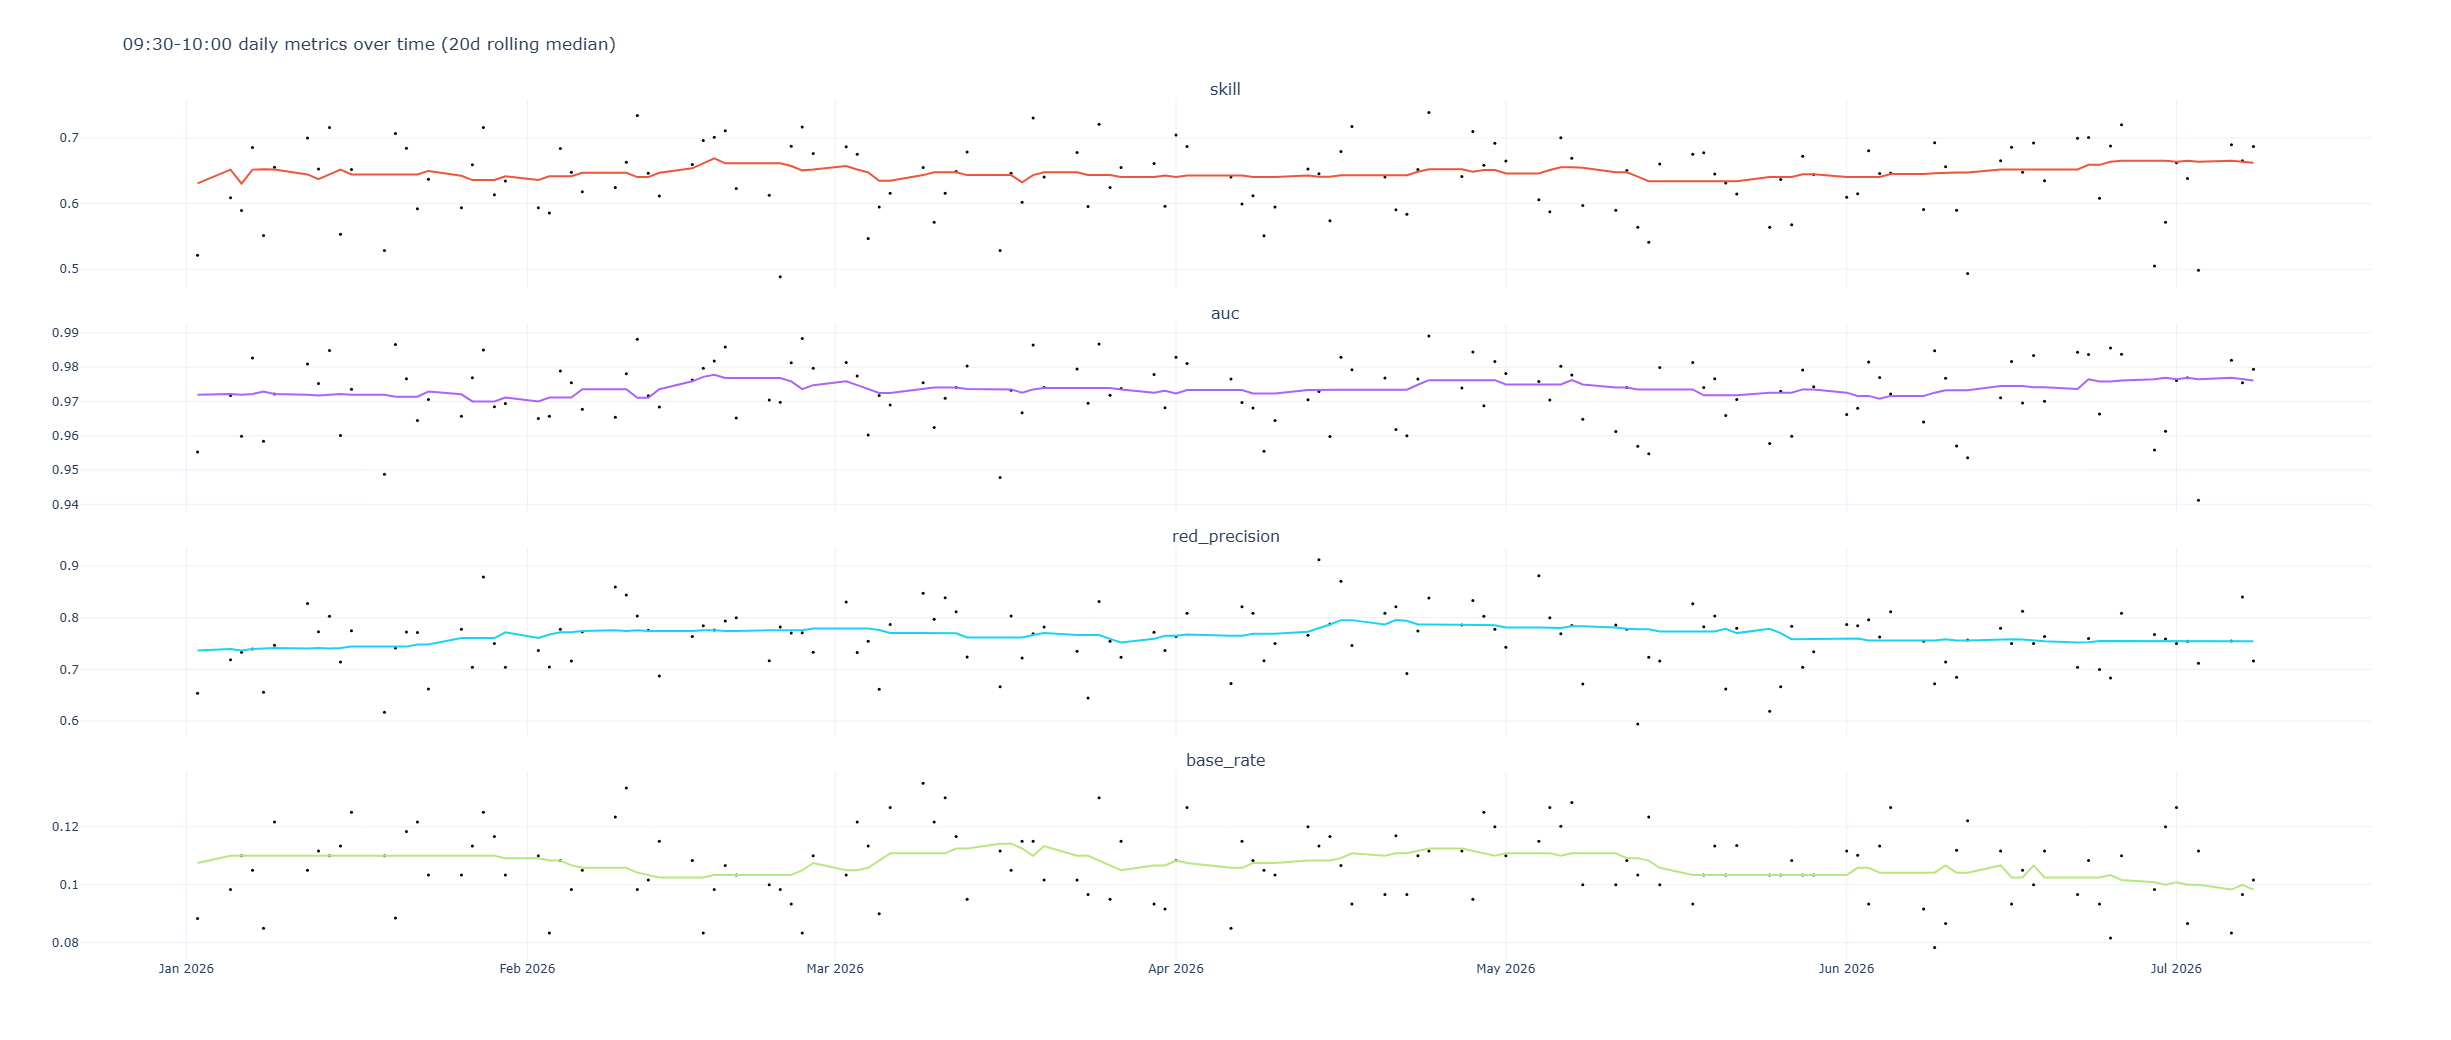

In [6]:
#pred = pd.read_parquet('data/stage-5/pred_fullspan_5c2raw_01-2025_6s.parquet')
ts = window_over_time(pred,  "09:30", "10:00") 